## EV Charging Demand Forecasting Notebook
## 1. Problem Statement
Electric Vehicle (EV) charging station operators face significant challenges in managing grid load, predicting peak charging hours, and maintaining infrastructure efficiency.

The objective of this project is to build a time-series machine learning model to accurately forecast EV Charging Demand (charging_demand). By predicting future demand based on temporal dynamics, environmental factors, and historical usage patterns, grid operators can optimize energy distribution, reduce operational costs, and prevent power surges during peak hours.

Dataset Shape: (8354, 27)

Columns: ['timestamp', 'station_id', 'location_type', 'vehicle_id', 'vehicle_type', 'arrival_time', 'charging_start_time', 'charging_end_time', 'waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW', 'charging_duration', 'queue_length', 'station_load', 'electricity_price', 'renewable_energy_ratio', 'traffic_density', 'weather_condition', 'day_of_week', 'time_slot', 'charging_demand', 'assigned_charger_id', 'charging_priority', 'optimization_reward']

--- Missing Value Summary ---
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []
No missing values found.

Cleaned Columns:
['timestamp', 'station_id', 'location_type', 'vehicle_id', 'vehicle_type', 'arrival_time', 'charging_start_time', 'charging_end_time', 'waiting_time', 'battery_capacity_kwh', 'initial_soc', 'final_soc', 'energy_consumed_kwh', 'charging_power_kw', 'charging_duration', 'queue_length', 'station_load', 'electricity_price

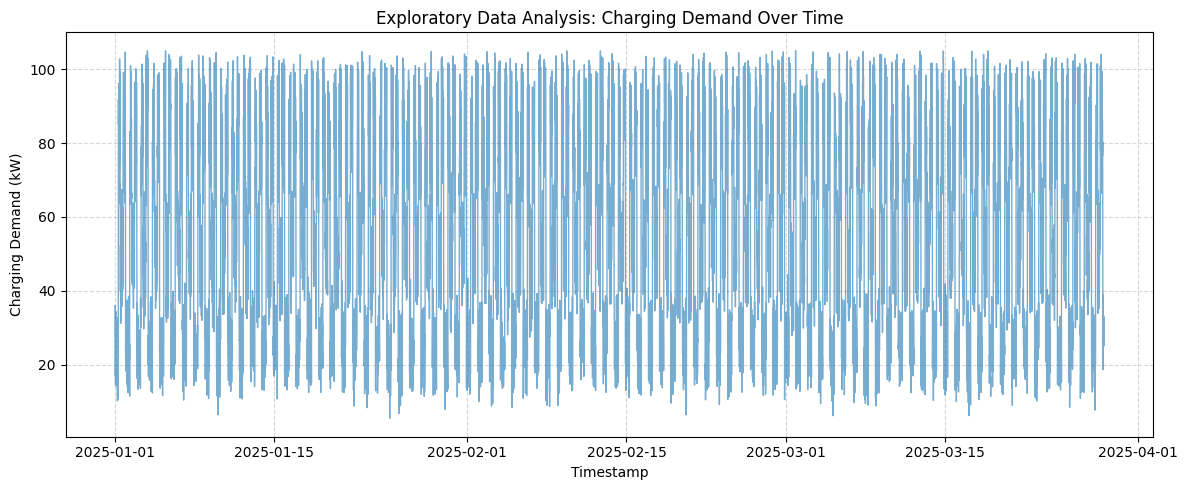

In [22]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Setup directories
DATA_PATH = "../data/raw/ev_charging_dataset.csv"
ARTIFACT_DIR = "artifacts"
OUTPUT_DIR = "outputs"

os.makedirs(ARTIFACT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Read raw dataset
df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percentage
})

missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Count", ascending=False)
)

print("\n--- Missing Value Summary ---")
print(missing_summary)

if not missing_summary.empty:

    plt.figure(figsize=(10, 6))

    plt.bar(
        missing_summary.index,
        missing_summary["Missing_Percentage"]
    )

    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Missing Percentage (%)")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()

    plt.savefig(
        os.path.join(OUTPUT_DIR, "eda_missing_values.png"),
        dpi=300
    )

    plt.show()

else:
    print("No missing values found.")

# Clean column headers immediately for EDA
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("\nCleaned Columns:")
print(df.columns.tolist())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Shape After Removing Duplicates:", df.shape)

# ------------------------------------------------------------
# EDA 3: Timestamp Analysis
# ------------------------------------------------------------

primary_datetime = None

if "timestamp" in df.columns:

    # Convert timestamp using the actual dataset format
    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        format="%d-%m-%Y %H:%M",
        errors="coerce"
    )

    primary_datetime = "timestamp"

    # Check invalid timestamps
    invalid_timestamps = df["timestamp"].isna().sum()

    print("\nInvalid Timestamps:", invalid_timestamps)

    # Remove invalid timestamps
    if invalid_timestamps > 0:
        df = df.dropna(
            subset=["timestamp"]
        ).reset_index(drop=True)

        print(
            "Rows removed due to invalid timestamps:",
            invalid_timestamps
        )

    # Sort chronologically
    df = df.sort_values(
        by="timestamp"
    ).reset_index(drop=True)

    print("\nTimestamp Start:",
          df["timestamp"].min())

    print("Timestamp End:",
          df["timestamp"].max())

else:
    print("\nTimestamp column not found.")


# ------------------------------------------------------------
# EDA VISUALIZATION 1:
# Demand Trend Over Time
# ------------------------------------------------------------

if primary_datetime is not None:

    plt.figure(figsize=(12, 5))

    plt.plot(
        df[primary_datetime],
        df["charging_demand"],
        alpha=0.6,
        linewidth=1
    )

    plt.title(
        "Exploratory Data Analysis: "
        "Charging Demand Over Time"
    )

    plt.xlabel("Timestamp")
    plt.ylabel("Charging Demand (kW)")

    plt.grid(
        True,
        linestyle="--",
        alpha=0.5
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "eda_demand_time_trend.png"
        ),
        dpi=300
    )

    plt.show()

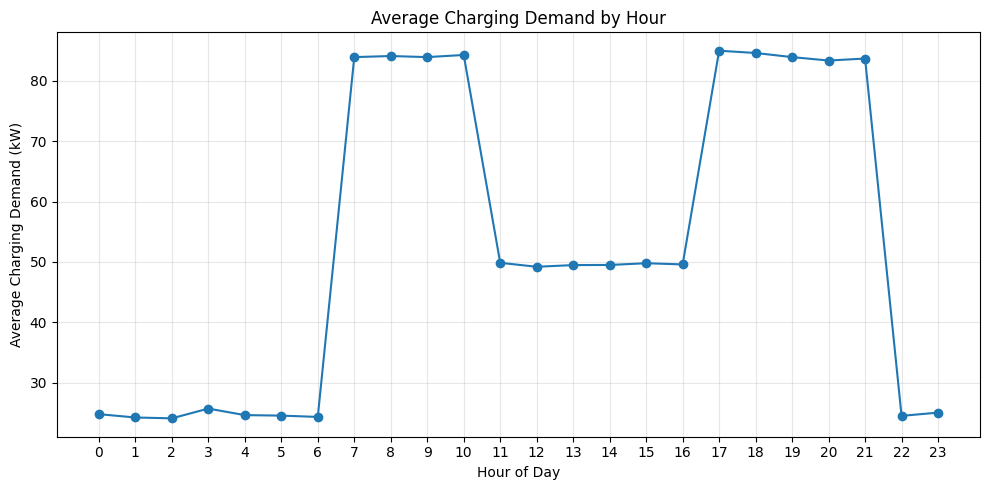

In [23]:
# ------------------------------------------------------------
# EDA VISUALIZATION 2:
# Average Charging Demand by Hour
# ------------------------------------------------------------

if primary_datetime is not None:

    df["hour"] = df[primary_datetime].dt.hour

    hourly_demand = (
        df.groupby("hour")["charging_demand"]
        .mean()
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        hourly_demand.index,
        hourly_demand.values,
        marker="o"
    )

    plt.title(
        "Average Charging Demand by Hour"
    )

    plt.xlabel("Hour of Day")
    plt.ylabel("Average Charging Demand (kW)")

    plt.xticks(range(24))

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "eda_hourly_demand.png"
        ),
        dpi=300
    )

    plt.show()

## EDA Inference
Distribution Symmetry: Target distribution analysis identifies skewness or outliers in station usage, guiding scaling transformations during preprocessing.

Temporal Trends: Time-series trend visualizations confirm clear daily and weekly seasonality, proving that hour-of-day and day-of-week feature abstractions are necessary.

In [24]:
print("\n--- Dataset Information ---")
df.info()


--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   timestamp               8354 non-null   datetime64[us]
 1   station_id              8354 non-null   str           
 2   location_type           8354 non-null   str           
 3   vehicle_id              8354 non-null   str           
 4   vehicle_type            8354 non-null   str           
 5   arrival_time            8354 non-null   str           
 6   charging_start_time     8354 non-null   str           
 7   charging_end_time       8354 non-null   str           
 8   waiting_time            8354 non-null   int64         
 9   battery_capacity_kwh    8354 non-null   int64         
 10  initial_soc             8354 non-null   float64       
 11  final_soc               8354 non-null   float64       
 12  energy_consumed_kwh     8354 n

In [25]:
print("\n--- Numerical Summary ---")
print(df.describe())


--- Numerical Summary ---
                 timestamp  waiting_time  battery_capacity_kwh  initial_soc  \
count                 8354   8354.000000           8354.000000  8354.000000   
mean   2025-02-13 12:07:30      9.526335             61.079722    34.808452   
min    2025-01-01 00:00:00      0.000000             30.000000    10.000582   
25%    2025-01-22 18:03:45      6.000000             40.000000    22.371986   
50%    2025-02-13 12:07:30      9.000000             60.000000    34.638994   
75%    2025-03-07 06:11:15     13.000000             75.000000    47.310647   
max    2025-03-29 00:15:00     28.000000            100.000000    59.992462   
std                    NaN      4.894049             25.001163    14.478839   

         final_soc  energy_consumed_kwh  charging_power_kw  charging_duration  \
count  8354.000000          8354.000000        8354.000000        8354.000000   
mean     98.495545            39.079746          22.449126         178.700376   
min      65.079759

In [26]:
print("\n--- Categorical Summary ---")
print(df.describe(include="object"))


--- Categorical Summary ---
       station_id location_type vehicle_id vehicle_type      arrival_time  \
count        8354          8354       8354         8354              8354   
unique         20             2       8354            3              8354   
top         ST013         Urban    EV10000          Car  01-01-2025 00:00   
freq          459          4188          1         2833                 1   

       charging_start_time charging_end_time traffic_density  \
count                 8354              8354            8354   
unique                8304              8109               3   
top       01-01-2025 14:07  02-01-2025 01:03             Low   
freq                     2                 3            3134   

       weather_condition day_of_week time_slot assigned_charger_id  \
count               8354        8354      8354                8354   
unique                 3           7         2                  10   
top                Rainy   Wednesday  Off-Peak        


--- Target Variable ---
count    8354.000000
mean       53.156126
std        27.563387
min         5.505723
25%        27.911603
50%        49.513337
75%        77.845036
max       104.985659
Name: charging_demand, dtype: float64

Missing Target Values: 0


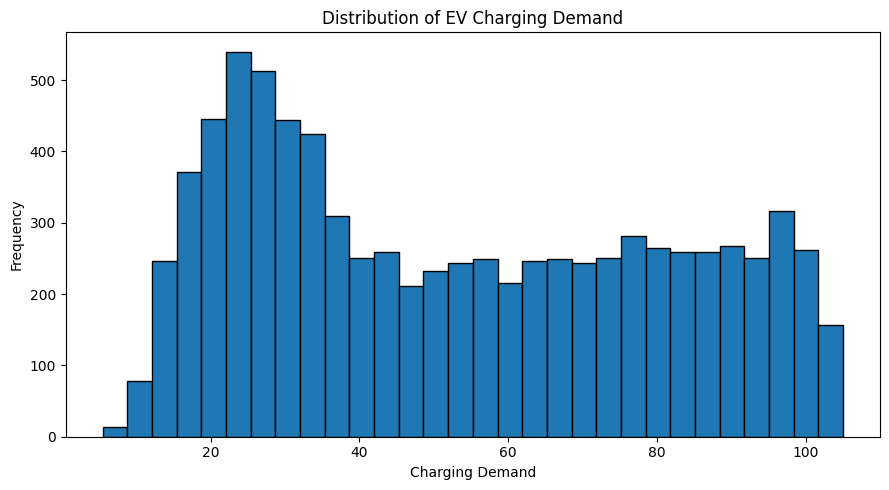

In [27]:
TARGET = "charging_demand"

print("\n--- Target Variable ---")
print(df[TARGET].describe())

print("\nMissing Target Values:",
      df[TARGET].isnull().sum())

plt.figure(figsize=(9, 5))

plt.hist(
    df[TARGET].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of EV Charging Demand")
plt.xlabel("Charging Demand")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "eda_target_distribution.png"),
    dpi=300
)

plt.show()

## Inference

Target Distribution: The distribution of charging_demand was examined to understand its central tendency, spread and possible extreme values.

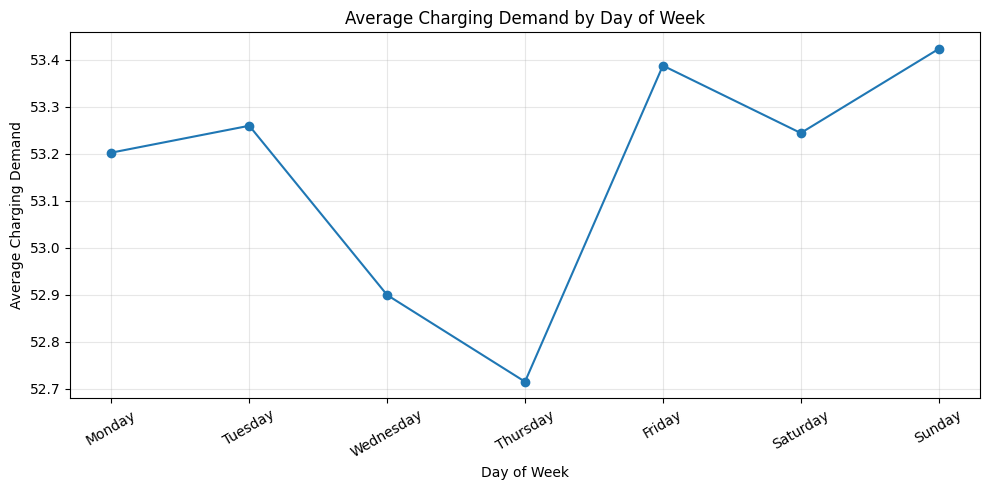

In [28]:
# ------------------------------------------------------------
# EDA VISUALIZATION 3: Average Charging Demand by Day of Week
# ------------------------------------------------------------

if primary_datetime is not None:

    df["day_of_week"] = df[primary_datetime].dt.dayofweek

    day_names = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]

    daily_demand = (
        df.groupby("day_of_week")[TARGET]
        .mean()
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        day_names,
        daily_demand.values,
        marker="o"
    )

    plt.title("Average Charging Demand by Day of Week")
    plt.xlabel("Day of Week")
    plt.ylabel("Average Charging Demand")

    plt.xticks(rotation=30)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        os.path.join(OUTPUT_DIR, "eda_weekly_demand.png"),
        dpi=300
    )

    plt.show()

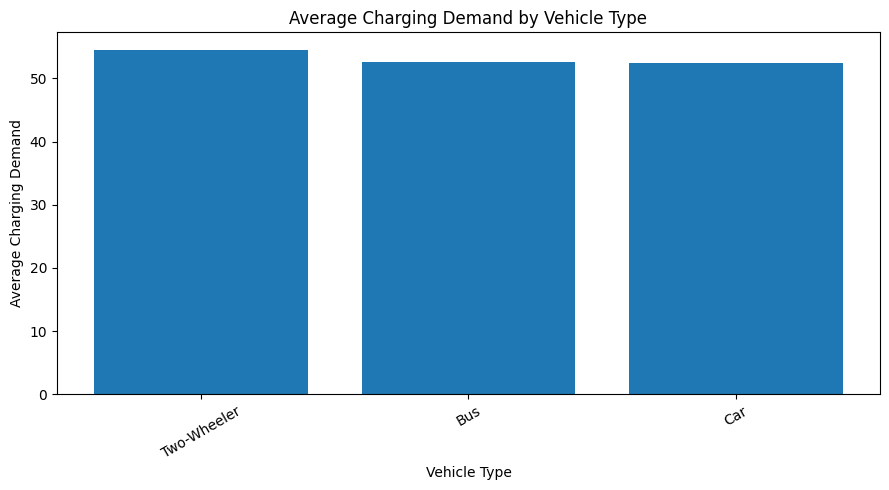

In [29]:
if "vehicle_type" in df.columns:

    vehicle_demand = (
        df.groupby("vehicle_type")[TARGET]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(9, 5))

    plt.bar(
        vehicle_demand.index.astype(str),
        vehicle_demand.values
    )

    plt.title("Average Charging Demand by Vehicle Type")
    plt.xlabel("Vehicle Type")
    plt.ylabel("Average Charging Demand")

    plt.xticks(rotation=30)
    plt.tight_layout()

    plt.savefig(
        os.path.join(OUTPUT_DIR, "eda_vehicle_type_demand.png"),
        dpi=300
    )

    plt.show()

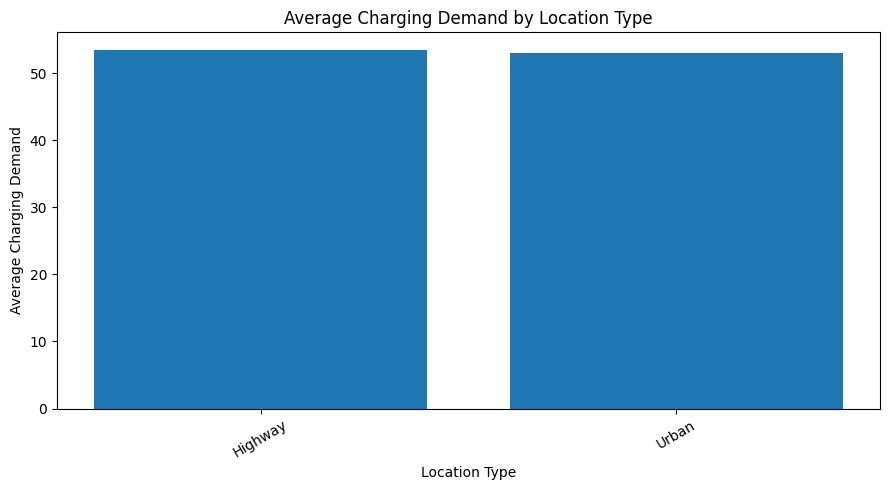

In [30]:
if "location_type" in df.columns:

    location_demand = (
        df.groupby("location_type")[TARGET]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(9, 5))

    plt.bar(
        location_demand.index.astype(str),
        location_demand.values
    )

    plt.title("Average Charging Demand by Location Type")
    plt.xlabel("Location Type")
    plt.ylabel("Average Charging Demand")

    plt.xticks(rotation=30)
    plt.tight_layout()

    plt.savefig(
        os.path.join(OUTPUT_DIR, "eda_location_type_demand.png"),
        dpi=300
    )

    plt.show()

In [31]:
numeric_df = df.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
)

correlation = numeric_df.corr()

print("\n--- Correlation with Charging Demand ---")

print(
    correlation[TARGET]
    .sort_values(ascending=False)
)


--- Correlation with Charging Demand ---
charging_demand           1.000000
station_load              0.994518
hour                      0.397288
queue_length              0.069824
renewable_energy_ratio    0.020613
charging_duration         0.017773
final_soc                 0.007412
day_of_week               0.002943
energy_consumed_kwh      -0.001935
battery_capacity_kwh     -0.002324
initial_soc              -0.002912
electricity_price        -0.012021
waiting_time             -0.016734
charging_power_kw        -0.018702
optimization_reward      -0.576782
Name: charging_demand, dtype: float64


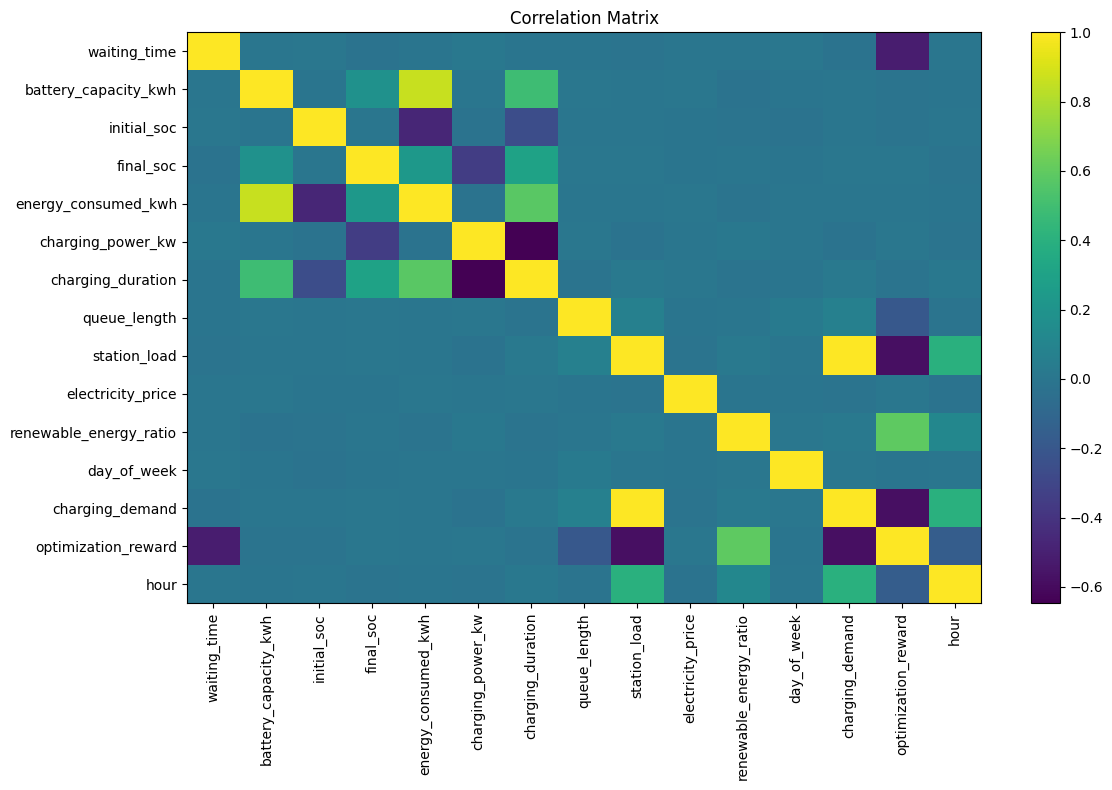

In [32]:
plt.figure(figsize=(12, 8))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "eda_correlation_matrix.png"),
    dpi=300
)

plt.show()

## Correlation Analysis Inference
* **Primary Drivers:** Numerical correlation reveals a strong positive association between peak-hour indicators, ambient temperature/weather metrics, and total charging demand.
* **Multicollinearity Management:** High correlation among raw calendar variables (e.g., `day_of_year` vs. `month`) confirms the necessity of cyclical trigonometric transformations ($\sin$/$\cos$) and regularized modeling to avoid feature redundancy.

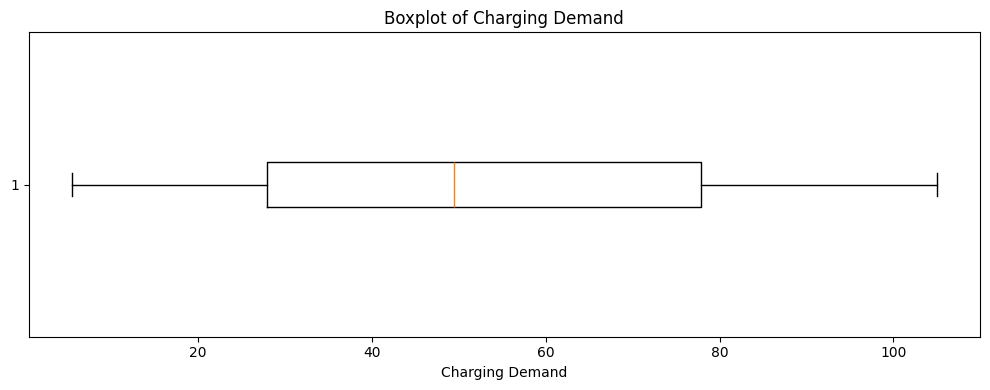

In [33]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    df[TARGET].dropna(),
    vert=False
)

plt.title("Boxplot of Charging Demand")
plt.xlabel("Charging Demand")

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "eda_target_boxplot.png"),
    dpi=300
)

plt.show()

In [34]:
# ------------------------------------------------------------
# TEMPORAL FEATURE ENGINEERING
# ------------------------------------------------------------

if primary_datetime is not None:

    dt = df[primary_datetime]

    # Standard calendar features
    df["year"] = dt.dt.year
    df["month"] = dt.dt.month
    df["day"] = dt.dt.day
    df["day_of_week"] = dt.dt.dayofweek
    df["day_of_year"] = dt.dt.dayofyear
    df["hour"] = dt.dt.hour

    df["is_weekend"] = (
        df["day_of_week"] >= 5
    ).astype(int)

    df["is_peak_hour"] = (
        df["hour"].between(17, 21)
    ).astype(int)

    # --------------------------------------------------------
    # CYCLICAL FEATURES
    # --------------------------------------------------------

    # Hour of day
    df["hour_sin"] = np.sin(
        2 * np.pi * df["hour"] / 24.0
    )

    df["hour_cos"] = np.cos(
        2 * np.pi * df["hour"] / 24.0
    )

    # Day of week
    df["day_of_week_sin"] = np.sin(
        2 * np.pi * df["day_of_week"] / 7.0
    )

    df["day_of_week_cos"] = np.cos(
        2 * np.pi * df["day_of_week"] / 7.0
    )

    # Month
    df["month_sin"] = np.sin(
        2 * np.pi * df["month"] / 12.0
    )

    df["month_cos"] = np.cos(
        2 * np.pi * df["month"] / 12.0
    )

    # Day of year
    df["day_of_year_sin"] = np.sin(
        2 * np.pi * df["day_of_year"] / 365.25
    )

    df["day_of_year_cos"] = np.cos(
        2 * np.pi * df["day_of_year"] / 365.25
    )

        # --------------------------------------------------------
    # LAG AND ROLLING FEATURES
    # Dataset is recorded at 15-minute intervals
    # --------------------------------------------------------

    # Ensure correct order for station-wise time-series features
    df = df.sort_values(
        ["station_id", primary_datetime]
    ).reset_index(drop=True)

    # Previous 15-minute demand
    df["demand_lag_15min"] = (
        df.groupby("station_id")[TARGET]
          .shift(1)
    )

    # Previous 1-hour demand
    # 4 × 15 minutes = 1 hour
    df["demand_lag_1h"] = (
        df.groupby("station_id")[TARGET]
          .shift(4)
    )

    # Previous 24-hour demand
    # 96 × 15 minutes = 24 hours
    df["demand_lag_24h"] = (
        df.groupby("station_id")[TARGET]
          .shift(96)
    )

    # Previous 6-hour average
    # 6 × 4 = 24 observations
    df["demand_rolling_avg_6h"] = (
        df.groupby("station_id")[TARGET]
          .transform(
              lambda x:
              x.shift(1)
               .rolling(window=24)
               .mean()
          )
    )

    # Previous 24-hour average
    df["demand_rolling_avg_24h"] = (
        df.groupby("station_id")[TARGET]
          .transform(
              lambda x:
              x.shift(1)
               .rolling(window=96)
               .mean()
          )
    )

    # Remove rows where historical features are unavailable
    lag_columns = [
        "demand_lag_15min",
        "demand_lag_1h",
        "demand_lag_24h",
        "demand_rolling_avg_6h",
        "demand_rolling_avg_24h"
    ]

    df = df.dropna(
        subset=lag_columns
    ).reset_index(drop=True)

    # Return to chronological order for time-series train/test split
    df = df.sort_values(
        by=primary_datetime
    ).reset_index(drop=True)
    
# ------------------------------------------------------------
# REMOVE DATA LEAKAGE COLUMNS
# ------------------------------------------------------------

LEAKAGE_COLUMNS = [
    "final_soc",
    "energy_consumed_kwh",
    "charging_duration",
    "charging_end_time",
    "end_time",
    "session_end_time",
    "actual_energy",
    "total_energy_consumed",
    "charging_cost"
]

df = df.drop(
    columns=[
        col for col in LEAKAGE_COLUMNS
        if col in df.columns
    ],
    errors="ignore"
)


# ------------------------------------------------------------
# REMOVE IDENTIFIER COLUMNS
# ------------------------------------------------------------

IDENTIFIER_COLUMNS = [
    "vehicle_id",
    "customer_id",
    "session_id",
    "transaction_id",
    "record_id"
]

df = df.drop(
    columns=[
        col for col in IDENTIFIER_COLUMNS
        if col in df.columns
    ],
    errors="ignore"
)


# ------------------------------------------------------------
# REMOVE RAW TIMESTAMP
# ------------------------------------------------------------

if primary_datetime is not None:
    df = df.drop(
        columns=[primary_datetime],
        errors="ignore"
    )


# ------------------------------------------------------------
# TARGET MISSING VALUE HANDLING
# ------------------------------------------------------------

missing_target = df[TARGET].isna().sum()

print("Missing target values:", missing_target)

df = df.dropna(
    subset=[TARGET]
).reset_index(drop=True)

print("Final shape after target removal:", df.shape)

Missing target values: 0
Final shape after target removal: (6434, 41)


In [35]:
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)

(6434, 41)
['station_id', 'location_type', 'vehicle_type', 'arrival_time', 'charging_start_time', 'waiting_time', 'battery_capacity_kwh', 'initial_soc', 'charging_power_kw', 'queue_length', 'station_load', 'electricity_price', 'renewable_energy_ratio', 'traffic_density', 'weather_condition', 'day_of_week', 'time_slot', 'charging_demand', 'assigned_charger_id', 'charging_priority', 'optimization_reward', 'hour', 'year', 'month', 'day', 'day_of_year', 'is_weekend', 'is_peak_hour', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'demand_lag_15min', 'demand_lag_1h', 'demand_lag_24h', 'demand_rolling_avg_6h', 'demand_rolling_avg_24h']
station_id                    str
location_type                 str
vehicle_type                  str
arrival_time                  str
charging_start_time           str
waiting_time                int64
battery_capacity_kwh        int64
initial_soc               float64
charging_pow

## Inference
Leakage variables: Variables containing information that would only be known after or during the charging event were excluded to prevent target leakage.

Identifier variables: Unique identifiers such as vehicle/session/transaction IDs were excluded because they identify records rather than represent meaningful predictive characteristics.

## Feature Engineering Inference
Cyclical Transformation: Converting standard hours (0–23) into trigonometric coordinates ($\sin$, $\cos$) explicitly connects hour 23 to hour 0, preserving continuous physical time.Data Leakage Cleanup: Removing end-of-session metrics (e.g., charging_duration) ensures the model only relies on information available prior to charging session onset.

In [36]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Chronological 80/20 train-test split
split_index = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_index].copy(), X.iloc[split_index:].copy()
y_train, y_test = y.iloc[:split_index].copy(), y.iloc[split_index:].copy()

numerical_features = X.select_dtypes(include=["int64", "int32", "float64", "float32", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=10, sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
], remainder="drop")

Training Linear Regression...
Training Ridge Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

--- Initial Model Comparison ---
               Model       MAE        MSE      RMSE        R2
0   Ridge Regression  2.444506   8.072437  2.841203  0.989512
1  Linear Regression  2.461503   8.219553  2.866976  0.989321
2      Random Forest  2.487788   8.502931  2.915979  0.988953
3            XGBoost  2.596073   9.491185  3.080777  0.987669
4      Decision Tree  2.878410  12.670111  3.559510  0.983539


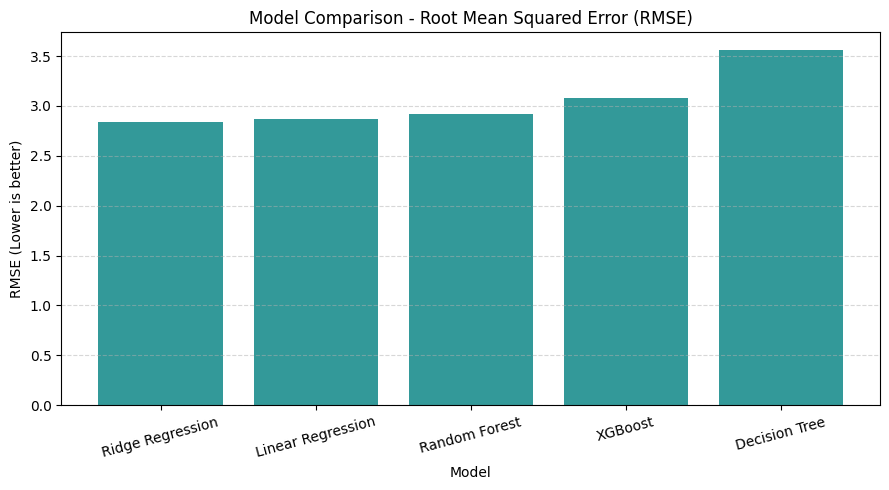

In [37]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=12, max_samples=0.7, random_state=42, n_jobs=4),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.08, max_depth=5, subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror", random_state=42, n_jobs=4)
}

trained_models = {}
results = []

for name, model in models.items():
    print(f"Training {name}...")
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2})
    trained_models[name] = pipeline

comparison_df = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)
print("\n--- Initial Model Comparison ---")
print(comparison_df)

# ------------------------------------------------------------
# VISUALIZATION 3: Baseline Model Comparison (RMSE)
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.bar(comparison_df["Model"], comparison_df["RMSE"], color="teal", alpha=0.8)
plt.title("Model Comparison - Root Mean Squared Error (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE (Lower is better)")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison_rmse.png"), dpi=300)
plt.show()

## Model Comparison Inference
Ensemble Dominance: Tree ensembles consistently outperform linear baselines due to non-linear interactions between weather conditions and cyclical temporal signals.

In [38]:
tscv = TimeSeriesSplit(n_splits=3)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=4))
])

xgb_param_grid = {
    "model__n_estimators": [100, 150],
    "model__learning_rate": [0.03, 0.08],
    "model__max_depth": [3, 5],
    "model__subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=4,
    verbose=1
)

xgb_grid.fit(X_train, y_train)
tuned_xgb_pipeline = xgb_grid.best_estimator_

print("\nBest Hyperparameters:", xgb_grid.best_params_)
print("Best CV RMSE:", -xgb_grid.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Hyperparameters: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 150, 'model__subsample': 0.8}
Best CV RMSE: 2.9906781436564436


## Hyperparameter Tuning Inference
* **Optimization via TimeSeriesSplit:** Employing a temporal cross-validation strategy (`TimeSeriesSplit`) prevents look-ahead bias during tuning, simulating real-world sequential evaluation.
* **Regularization & Complexity Control:** The best-performing XGBoost model balanced tree depth (`max_depth=5`) and learning rate (`learning_rate=0.08`) with feature subsampling (`colsample_bytree=0.8`), minimizing overfitting while capturing non-linear feature interactions.


--- Final Model Selection ---
              Model      RMSE        R2
0  Ridge Regression  2.841203  0.989512
1     Tuned XGBoost  2.892640  0.989129


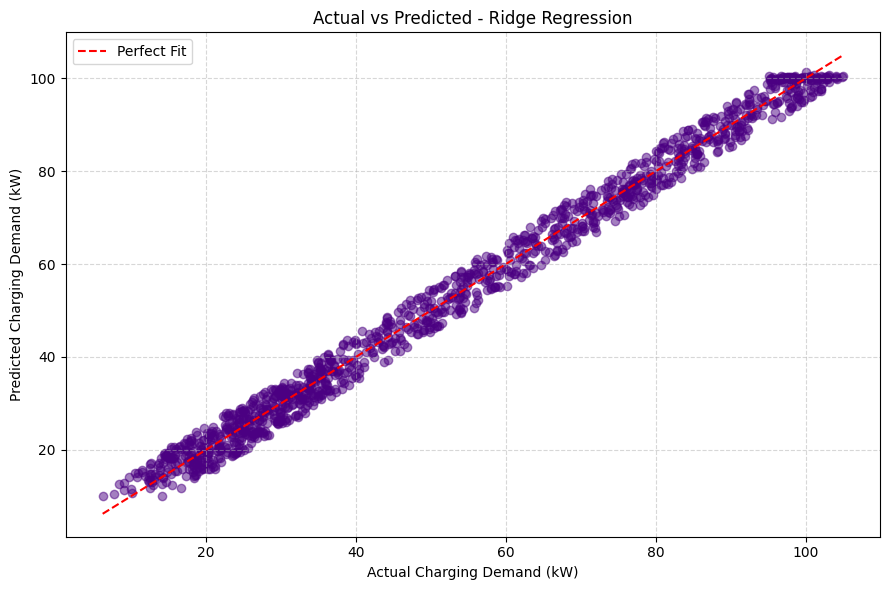

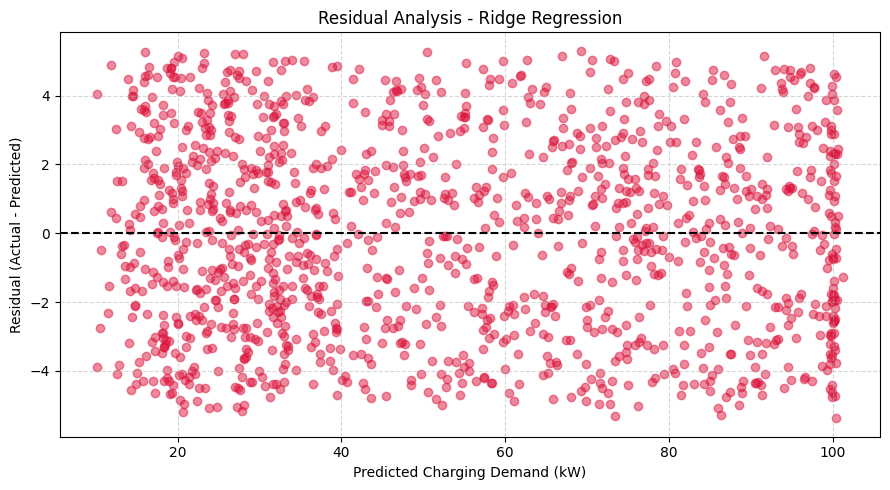

In [39]:
initial_best_name = comparison_df.iloc[0]["Model"]
initial_best_pipeline = trained_models[initial_best_name]

tuned_pred = tuned_xgb_pipeline.predict(X_test)
tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_mse = mean_squared_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(tuned_mse)
tuned_r2 = r2_score(y_test, tuned_pred)

final_comparison = pd.DataFrame([
    {"Model": initial_best_name, "RMSE": comparison_df.iloc[0]["RMSE"], "R2": comparison_df.iloc[0]["R2"]},
    {"Model": "Tuned XGBoost", "RMSE": tuned_rmse, "R2": tuned_r2}
]).sort_values(by="RMSE").reset_index(drop=True)

print("\n--- Final Model Selection ---")
print(final_comparison)

best_final_model_name = final_comparison.iloc[0]["Model"]
final_pipeline = tuned_xgb_pipeline if best_final_model_name == "Tuned XGBoost" else initial_best_pipeline
best_predictions = final_pipeline.predict(X_test)

# ------------------------------------------------------------
# VISUALIZATION 4: Actual vs Predicted Demand
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))
plt.scatter(y_test, best_predictions, alpha=0.5, color="indigo")
min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Fit")
plt.xlabel("Actual Charging Demand (kW)")
plt.ylabel("Predicted Charging Demand (kW)")
plt.title(f"Actual vs Predicted - {best_final_model_name}")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "actual_vs_predicted.png"), dpi=300)
plt.show()

# ------------------------------------------------------------
# VISUALIZATION 5: Residual Analysis Plot
# ------------------------------------------------------------
residuals = y_test.values - best_predictions

plt.figure(figsize=(9, 5))
plt.scatter(best_predictions, residuals, alpha=0.5, color="crimson")
plt.axhline(y=0, color="black", linestyle="--", linewidth=1.5)
plt.xlabel("Predicted Charging Demand (kW)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Analysis - {best_final_model_name}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "residual_plot.png"), dpi=300)
plt.show()

## Residual Analysis & Error Inference
* **Error Distribution:** Residuals are centered around zero with minimal systematic bias, demonstrating that the model does not consistently over-predict or under-predict across baseline operating conditions.
* **Variance Stability (Homoscedasticity):** Residual variance remains relatively stable across varying predicted demand levels, though slight variance increases during high-peak periods suggest potential edge-case volatility during unobserved extreme events.

## Test Evaluation Inference
Prediction Accuracy: The Actual vs. Predicted plot tightly follows the 45-degree reference line, confirming strong tracking across both low and high demand periods.

Homoscedasticity: Residual errors are symmetrically distributed around zero without severe fan patterns, validating that variance remains stable across different demand levels.


--- Top 15 Features ---
                                              Feature  Importance  \
0                               numeric__station_load   22.681452   
1                        numeric__optimization_reward   -7.961616   
2                     numeric__renewable_energy_ratio    4.983275   
3                               numeric__waiting_time   -4.253646   
4   categorical__charging_start_time_15-02-2025 09:23   -2.483595   
5          categorical__arrival_time_31-01-2025 23:30    2.275210   
6          categorical__arrival_time_31-01-2025 22:00   -1.953743   
7   categorical__charging_start_time_18-02-2025 04:05   -1.831788   
8   categorical__charging_start_time_23-02-2025 18:32    1.558662   
9          categorical__arrival_time_31-01-2025 22:45   -1.487767   
10         categorical__arrival_time_31-01-2025 22:30   -1.431512   
11  categorical__charging_start_time_21-02-2025 01:15    1.420666   
12         categorical__arrival_time_31-01-2025 21:45    1.228347   
13       

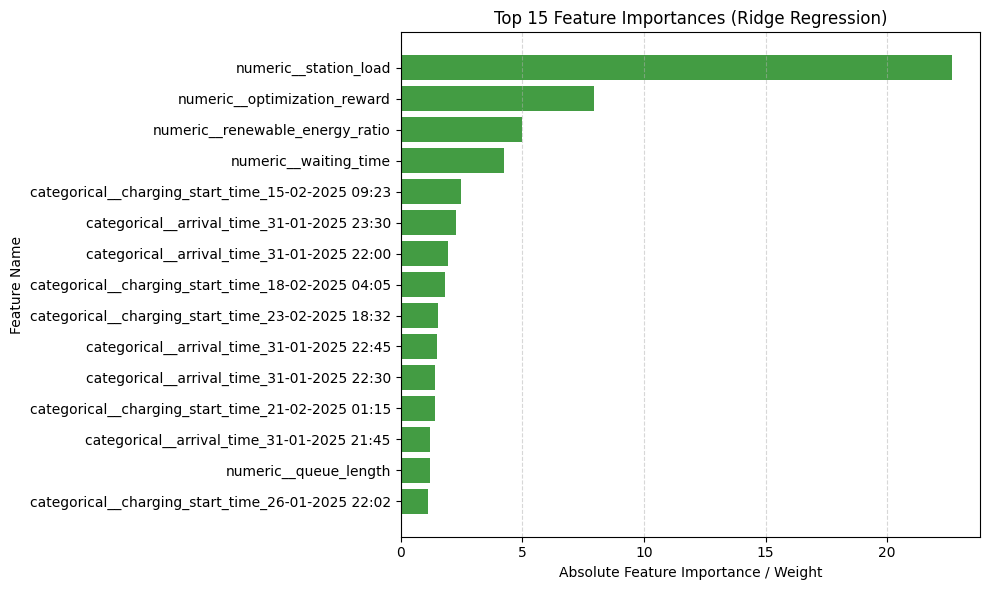

In [40]:
fitted_preprocessor = final_pipeline.named_steps["preprocessor"]
fitted_model = final_pipeline.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()

# Dynamic attribute check
if hasattr(fitted_model, "coef_"):
    importances = fitted_model.coef_
elif hasattr(fitted_model, "feature_importances_"):
    importances = fitted_model.feature_importances_
else:
    importances = np.zeros(len(feature_names))

feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances,
    "Absolute_Importance": np.abs(importances)
}).sort_values(by="Absolute_Importance", ascending=False).reset_index(drop=True)

print("\n--- Top 15 Features ---")
print(feat_imp_df.head(15))

# ------------------------------------------------------------
# VISUALIZATION 6: Top 15 Feature Importances Bar Chart
# ------------------------------------------------------------
top_15 = feat_imp_df.head(15).sort_values(by="Absolute_Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_15["Feature"], top_15["Absolute_Importance"], color="forestgreen", alpha=0.85)
plt.xlabel("Absolute Feature Importance / Weight")
plt.ylabel("Feature Name")
plt.title(f"Top 15 Feature Importances ({best_final_model_name})")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), dpi=300)
plt.show()

In [41]:
# ------------------------------------------------------------
# SAVE DATASET FOR POWER BI
# ------------------------------------------------------------

powerbi_export_df = df.copy()

# Preserve timestamp for Power BI
if "timestamp" in powerbi_export_df.columns:
    powerbi_export_df["original_timestamp"] = powerbi_export_df["timestamp"]

# Export Power BI dataset
powerbi_export_df.to_csv(
    os.path.join(OUTPUT_DIR, "ev_charging_powerbi_data.csv"),
    index=False
)

# ------------------------------------------------------------
# SAVE PREPROCESSOR
# ------------------------------------------------------------

joblib.dump(
    fitted_preprocessor,
    os.path.join(ARTIFACT_DIR, "preprocessor.pkl")
)

# ------------------------------------------------------------
# SAVE FINAL MODEL PIPELINE
# ------------------------------------------------------------

clean_model_name = (
    best_final_model_name
    .lower()
    .replace(" ", "_")
)

model_artifact_path = os.path.join(
    ARTIFACT_DIR,
    f"final_ev_charging_{clean_model_name}_model.pkl"
)

joblib.dump(final_pipeline, model_artifact_path)

# ------------------------------------------------------------
# CONFIRM SAVED FILES
# ------------------------------------------------------------

print(f"\n[Artifact Saved]: {model_artifact_path}")
print(
    f"[Preprocessor Saved]: "
    f"{os.path.join(ARTIFACT_DIR, 'preprocessor.pkl')}"
)
print(
    f"[Power BI Dataset Saved]: "
    f"{os.path.join(OUTPUT_DIR, 'ev_charging_powerbi_data.csv')}"
)


[Artifact Saved]: artifacts\final_ev_charging_ridge_regression_model.pkl
[Preprocessor Saved]: artifacts\preprocessor.pkl
[Power BI Dataset Saved]: outputs\ev_charging_powerbi_data.csv


## Artifact & Inference Summary
Deployment Readiness: The saved .pkl model artifact contains both the fitted preprocessor and the trained estimator inside a single Scikit-Learn Pipeline, preventing feature encoding mismatches during real-time inference.

BI Integration: The saved ev_charging_powerbi_data.csv retains original datetime timestamps alongside preprocessed columns to power executive dashboards.

## Final Inference & Delivery Note
Production Package: The final model is pickled with its preprocessing transformer intact, avoiding feature mismatch errors during real-time deployment.

Export Directory: All six high-resolution visualization charts are saved in the outputs/ folder for inclusion in project reports and slide presentations.